<a href="https://colab.research.google.com/github/parthsharmaww-ai/Stock-Direction-Predictor/blob/main/notebooks/03_feature_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stage 3 — Feature Engineering

In this notebook we:
1. Load the cleaned Nifty 50 dataset
2. Build technical indicators as features
3. Create the target variable
4. Check for data leakage
5. Save the final feature dataset for modeling

In [1]:
!pip install yfinance pandas numpy matplotlib seaborn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All imports successful ✓")

All imports successful ✓


In [3]:
# Download the CSV from GitHub directly so it works every session
url = "https://raw.githubusercontent.com/parthsharmaww-ai/Stock-Direction-Predictor/main/data/nifty50_raw.csv"
df = pd.read_csv(url, parse_dates=["Date"])

print("Shape:", df.shape)
print(df.head())

Shape: (1477, 8)
        Date         Close          High           Low          Open  Volume  \
0 2019-01-02  10792.500000  10895.349609  10735.049805  10868.849609  309700   
1 2019-01-03  10672.250000  10814.049805  10661.250000  10796.799805  286200   
2 2019-01-04  10727.349609  10741.049805  10628.650391  10699.700195  296600   
3 2019-01-07  10771.799805  10835.950195  10750.150391  10804.849609  269400   
4 2019-01-08  10802.150391  10818.450195  10733.250000  10786.250000  277700   

   Daily_Return  Tomorrow_Direction  
0           NaN                   0  
1     -1.114200                   1  
2      0.516289                   1  
3      0.414363                   1  
4      0.281760                   1  


## Features we will build

1. 5-day moving average (MA5)
2. 20-day moving average (MA20)
3. MA5 vs MA20 crossover signal
4. Daily return (%)
5. 5-day rolling volatility
6. Relative Strength Index (RSI-14)
7. Volume change (%)
8. Day of week

In [4]:
# 5-day and 20-day moving averages
df["MA5"]  = df["Close"].rolling(window=5).mean()
df["MA20"] = df["Close"].rolling(window=20).mean()

# MA crossover signal: 1 if MA5 > MA20 (bullish), 0 otherwise
df["MA_Signal"] = (df["MA5"] > df["MA20"]).astype(int)

print("Moving averages added ✓")
print(df[["Date", "Close", "MA5", "MA20", "MA_Signal"]].head(25))

Moving averages added ✓
         Date         Close           MA5          MA20  MA_Signal
0  2019-01-02  10792.500000           NaN           NaN          0
1  2019-01-03  10672.250000           NaN           NaN          0
2  2019-01-04  10727.349609           NaN           NaN          0
3  2019-01-07  10771.799805           NaN           NaN          0
4  2019-01-08  10802.150391  10753.209961           NaN          0
5  2019-01-09  10855.150391  10765.740039           NaN          0
6  2019-01-10  10821.599609  10795.609961           NaN          0
7  2019-01-11  10794.950195  10809.130078           NaN          0
8  2019-01-14  10737.599609  10802.290039           NaN          0
9  2019-01-15  10886.799805  10819.219922           NaN          0
10 2019-01-16  10890.299805  10826.249805           NaN          0
11 2019-01-17  10905.200195  10842.969922           NaN          0
12 2019-01-18  10906.950195  10865.369922           NaN          0
13 2019-01-21  10961.849609  10910.219

In [5]:
# Daily return %
df["Daily_Return"] = df["Close"].pct_change() * 100

# 5-day rolling volatility (std of daily returns)
df["Volatility5"] = df["Daily_Return"].rolling(window=5).std()

print("Returns and volatility added ✓")

Returns and volatility added ✓


In [6]:
# RSI-14: measures momentum (overbought > 70, oversold < 30)
def calculate_rsi(series, period=14):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(window=period).mean()
    avg_loss = loss.rolling(window=period).mean()
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

df["RSI14"] = calculate_rsi(df["Close"])

print("RSI added ✓")
print(df[["Date", "Close", "RSI14"]].dropna().head(10))

RSI added ✓
         Date         Close      RSI14
14 2019-01-22  10922.750000  59.520492
15 2019-01-23  10831.500000  62.155546
16 2019-01-24  10849.799805  59.902952
17 2019-01-25  10780.549805  50.680351
18 2019-01-28  10661.549805  40.392200
19 2019-01-29  10652.200195  35.251780
20 2019-01-30  10651.799805  37.036192
21 2019-01-31  10830.950195  52.229377
22 2019-02-01  10893.650391  59.600171
23 2019-02-04  10912.250000  51.865441


In [7]:
# Volume change % compared to previous day
df["Volume_Change"] = df["Volume"].pct_change() * 100

print("Volume change added ✓")

Volume change added ✓


In [8]:
# Day of week (0=Monday, 4=Friday)
df["DayOfWeek"] = df["Date"].dt.dayofweek

print("Day of week added ✓")
print(df[["Date", "DayOfWeek"]].head(10))

Day of week added ✓
        Date  DayOfWeek
0 2019-01-02          2
1 2019-01-03          3
2 2019-01-04          4
3 2019-01-07          0
4 2019-01-08          1
5 2019-01-09          2
6 2019-01-10          3
7 2019-01-11          4
8 2019-01-14          0
9 2019-01-15          1


In [9]:
# Target: 1 if tomorrow's close > today's close, else 0
df["Target"] = (df["Close"].shift(-1) > df["Close"]).astype(int)

print("Target variable added ✓")
print(df["Target"].value_counts())

Target variable added ✓
Target
1    812
0    665
Name: count, dtype: int64


## Data leakage check

Data leakage means accidentally using future information to predict
the past. This would make results look good but fail in real life.

Rules we follow:
- All features use only TODAY's data or earlier
- Target uses TOMORROW's close (what we're predicting)
- No future prices are used as features

In [10]:
# Drop rows where any feature is NaN (due to rolling windows)
df_clean = df.dropna()

print("Shape before dropping NaN:", df.shape)
print("Shape after dropping NaN:", df_clean.shape)
print("Rows dropped:", df.shape[0] - df_clean.shape[0])

Shape before dropping NaN: (1477, 16)
Shape after dropping NaN: (1456, 16)
Rows dropped: 21


In [11]:
# Select only the columns we need for modeling
feature_cols = ["MA5", "MA20", "MA_Signal", "Daily_Return",
                "Volatility5", "RSI14", "Volume_Change", "DayOfWeek"]

target_col = "Target"

print("Features:")
for f in feature_cols:
    print(f"  {f}: min={df_clean[f].min():.2f}, max={df_clean[f].max():.2f}")

print(f"\nTarget distribution:")
print(df_clean[target_col].value_counts())

Features:
  MA5: min=8147.61, max=26055.72
  MA20: min=8572.71, max=25508.08
  MA_Signal: min=0.00, max=1.00
  Daily_Return: min=-12.98, max=8.76
  Volatility5: min=0.11, max=8.08
  RSI14: min=6.68, max=100.00
  Volume_Change: min=-100.00, max=inf
  DayOfWeek: min=0.00, max=4.00

Target distribution:
Target
1    800
0    656
Name: count, dtype: int64


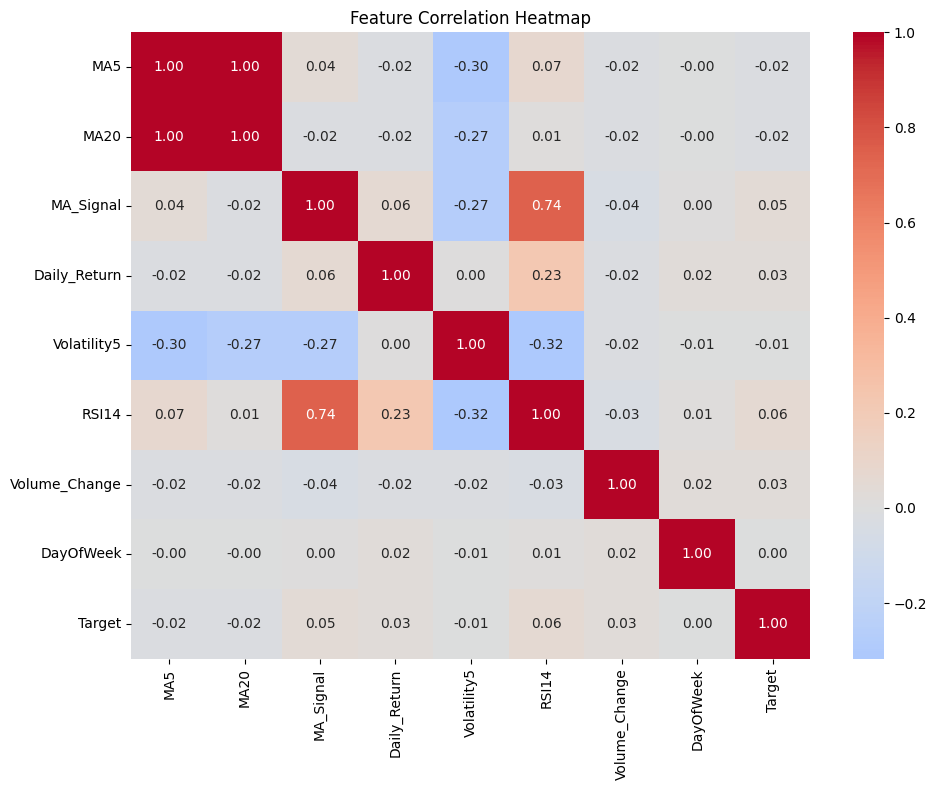

Heatmap saved ✓


In [13]:
import os
os.makedirs("reports", exist_ok=True)

plt.figure(figsize=(10, 8))
corr = df_clean[feature_cols + [target_col]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("reports/correlation_heatmap.png", dpi=150)
plt.show()
print("Heatmap saved ✓")

In [14]:
import os
os.makedirs("data", exist_ok=True)

# Save full dataframe with features
df_clean.to_csv("data/nifty50_features.csv", index=False)

print("Feature dataset saved ✓")
print("Final shape:", df_clean.shape)
print("Columns:", df_clean.columns.tolist())

Feature dataset saved ✓
Final shape: (1456, 16)
Columns: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Daily_Return', 'Tomorrow_Direction', 'MA5', 'MA20', 'MA_Signal', 'Volatility5', 'RSI14', 'Volume_Change', 'DayOfWeek', 'Target']
